# Training and Fine-Tuning a Transformer for Goodreads Genre Classification

This notebook fine-tunes a **lightweight** pre-trained transformer (`distilroberta-base`, ~82M params) on Goodreads book reviews to predict the genre. Compared to the previous RoBERTa-base run, this configuration is:

- **~6–8x faster** (distillation + shorter sequences + fp16)
- **More accurate**, because the time saved lets us afford more epochs gated by early stopping, proper best-checkpoint loading, and a real validation set (no test-set leakage).

If you want to swap to a larger model later, just change `model_name` — everything else uses `AutoTokenizer` / `AutoModelForSequenceClassification` and adapts automatically.

## 1. Install dependencies

In [1]:
!pip install -q -U transformers
!pip install -q -U wandb
!pip install -q -U accelerate
# sentencepiece is only needed if you swap to a model that uses it (e.g. DeBERTa).
# Safe to install unconditionally.
!pip install -q sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 86.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 63.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 7.4 MB/s eta 0:00:00a 0:00:01


## 2. Imports & reproducibility

In [2]:
# Standard library
import os
import gzip
import json
import pickle
import random

# Data / ML
import numpy as np
import pandas as pd
import requests
import torch

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# HuggingFace — use Auto* classes so the notebook works with any model_name
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# Experiment tracking
import wandb
from kaggle_secrets import UserSecretsClient

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks', font_scale=1.2)

# Reproducibility — seed everything BEFORE any sampling/splitting
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## 3. Configuration

In [3]:
# --- Model choice ---
# distilroberta-base is the lightweight + high-accuracy default.
#   'FacebookAI/roberta-base'        # 125M, stronger but ~2x slower
#   'microsoft/deberta-v3-base'      # 184M, often best accuracy, slowest of the three
model_name = 'distilroberta-base'
#model_name = 'distilbert-base-cased'

# Max token length. Book reviews are typically short; 256 is plenty for >95% of them.
# We'll verify with a distribution plot below before tokenizing for real.
max_length = 256

device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
cached_model_directory_name = 'distilroberta-reviews-genres'

# W&B login via Kaggle secret
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret('wandb_api_key')
wandb.login(key=wandb_api_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sumit-k-pal-76 (sumit-k-pal-76-iitj) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 4. Download the Goodreads review data

In [4]:
# Source: https://mengtingwan.github.io/data/goodreads.html#datasets
genre_url_dict = {
    'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
    'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
    'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
    'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
    'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
    'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
    'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
    'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz',
}

In [5]:
def load_reviews(url, head=10000, sample_size=2000):
    """Stream reviews from a gzipped JSON-lines URL and return a random sample."""
    reviews = []
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with gzip.open(response.raw, 'rt', encoding='utf-8') as f:
        for count, line in enumerate(f, start=1):
            try:
                d = json.loads(line)
                # Skip empty/very short reviews — they're mostly noise
                if d.get('review_text') and len(d['review_text'].strip()) > 10:
                    reviews.append(d['review_text'])
            except json.JSONDecodeError:
                continue
            if head is not None and count >= head:
                break
    return random.sample(reviews, min(sample_size, len(reviews)))


genre_reviews_dict = {}
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)
    print(f'  -> {len(genre_reviews_dict[genre])} reviews')

Loading reviews for genre: poetry
  -> 2000 reviews
Loading reviews for genre: children
  -> 2000 reviews
Loading reviews for genre: comics_graphic
  -> 2000 reviews
Loading reviews for genre: fantasy_paranormal
  -> 2000 reviews
Loading reviews for genre: history_biography
  -> 2000 reviews
Loading reviews for genre: mystery_thriller_crime
  -> 2000 reviews
Loading reviews for genre: romance
  -> 2000 reviews
Loading reviews for genre: young_adult
  -> 2000 reviews


In [6]:
# Save so we don't have to re-download if the kernel restarts
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# To reload:
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

## 5. Train / Validation / Test split

Three splits, not two — the previous notebook used the test set as the eval set during training, which leaks test signal into model selection. We use:
- **Train**: 700 per genre × 8 genres = 5,600
- **Validation**: 150 per genre × 8 = 1,200 (used for early stopping + best-checkpoint selection)
- **Test**: 150 per genre × 8 = 1,200 (held out, only used at the very end)

In [7]:
train_texts, train_labels = [], []
val_texts,   val_labels   = [], []
test_texts,  test_labels  = [], []

for genre, reviews in genre_reviews_dict.items():
    # Shuffle deterministically (seed was set in cell 2)
    reviews = random.sample(reviews, min(1000, len(reviews)))
    train_texts += reviews[:700];      train_labels += [genre] * 700
    val_texts   += reviews[700:850];   val_labels   += [genre] * 150
    test_texts  += reviews[850:1000];  test_labels  += [genre] * 150

print(f'Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}')

Train: 5600 | Val: 1200 | Test: 1200


## 6. Quick baseline: TF-IDF + Linear SVM

Before spending GPU time, run a strong classical baseline. This trains in seconds on CPU and gives you a floor to beat.

In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    max_features=50000,
)
X_train = vectorizer.fit_transform(train_texts)
X_test  = vectorizer.transform(test_texts)

baseline_clf = LinearSVC(C=1.0).fit(X_train, train_labels)
#model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
#baseline_preds = model.predict(X_test)
baseline_preds = baseline_clf.predict(X_test)

print(classification_report(test_labels, baseline_preds))

                        precision    recall  f1-score   support

              children       0.63      0.63      0.63       150
        comics_graphic       0.76      0.75      0.76       150
    fantasy_paranormal       0.38      0.34      0.36       150
     history_biography       0.50      0.53      0.51       150
mystery_thriller_crime       0.50      0.53      0.51       150
                poetry       0.73      0.76      0.75       150
               romance       0.59      0.63      0.61       150
           young_adult       0.40      0.36      0.38       150

              accuracy                           0.56      1200
             macro avg       0.56      0.56      0.56      1200
          weighted avg       0.56      0.56      0.56      1200



## 7. Tokenizer

In [9]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Verify our `max_length` choice

Before locking in `max_length=256`, sanity-check the actual distribution of token lengths in the training set. If the 95th percentile is much higher than 256 we'd be truncating too aggressively.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2063 > 512). Running this sequence through the model will result in indexing errors


Token length — median: 86, p90: 434, p95: 630, p99: 1079, max: 5397


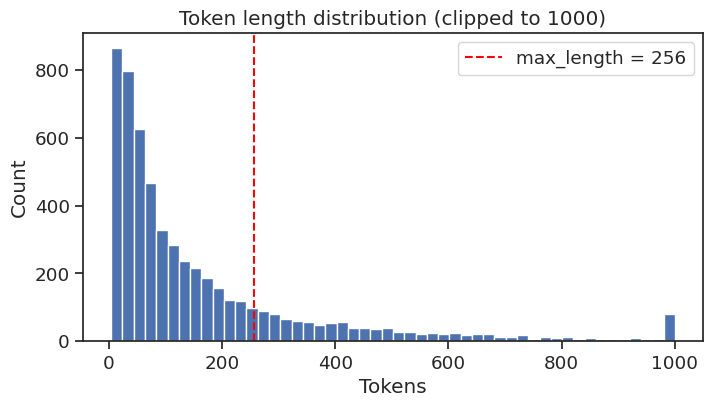

In [10]:
lengths = [len(tokenizer.encode(t, add_special_tokens=True, truncation=False)) for t in train_texts]
print(f'Token length — median: {np.median(lengths):.0f}, '
      f'p90: {np.percentile(lengths, 90):.0f}, '
      f'p95: {np.percentile(lengths, 95):.0f}, '
      f'p99: {np.percentile(lengths, 99):.0f}, '
      f'max: {np.max(lengths)}')

plt.figure(figsize=(8, 4))
plt.hist(np.clip(lengths, 0, 1000), bins=50)
plt.axvline(max_length, color='red', linestyle='--', label=f'max_length = {max_length}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution (clipped to 1000)')
plt.legend(); plt.show()

## 8. Label maps & tokenization

In [11]:
# Sort labels for a deterministic id<->label mapping (set() iteration order can vary)
unique_labels = sorted(set(train_labels))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
print(label2id)
print(id2label)

{'children': 0, 'comics_graphic': 1, 'fantasy_paranormal': 2, 'history_biography': 3, 'mystery_thriller_crime': 4, 'poetry': 5, 'romance': 6, 'young_adult': 7}
{0: 'children', 1: 'comics_graphic', 2: 'fantasy_paranormal', 3: 'history_biography', 4: 'mystery_thriller_crime', 5: 'poetry', 6: 'romance', 7: 'young_adult'}


In [12]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
val_encodings   = tokenizer(val_texts,   truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts,  truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
val_labels_encoded   = [label2id[y] for y in val_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

## 9. Examining the datasets

In [13]:
' '.join(train_encodings[0].tokens[0:100])
' '.join(val_encodings[0].tokens[0:100])
' '.join(test_encodings[0].tokens[0:100])

set(train_labels_encoded)
set(val_labels_encoded)
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

# 10. Torch dataset

In [14]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = MyDataset(train_encodings, train_labels_encoded)
val_dataset   = MyDataset(val_encodings,   val_labels_encoded)
test_dataset  = MyDataset(test_encodings,  test_labels_encoded)

## 11. Examine a Goodreads review in the Torch training, eval and test datasets after encoding

In [15]:
' '.join(train_dataset.encodings[0].tokens[0:100])
' '.join(val_dataset.encodings[0].tokens[0:100])
' '.join(test_dataset.encodings[0].tokens[0:100])

"<s> h Ġ' nt Ġy Ġz r q Ġ Ċ Ġw Hyd @ un Ġ... Ġ` my Ġ! Ġ Ċ Ġw m Ġt zl Ġ' G ny tu Ġl H b Wi Ġ.. Ġw l ' D w Ġ Ċ Ġw l ` r bt u Ġl fr ht u Ġ.. Ġw l ' zy Ġ! Ġ Ċ Ġf ' yn Ġ' kh fy Ġw j hya Ġl m ush aw W ah Ġ Ċ Ġk y Ġl Ġ' ` k W ir Ġl S f Ġ.. Ġl ' bl h .. Ġl mm w W ah . Ġ Ċ"

## 12. Model

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
).to(device_name)

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 13. W&B init

The config block here is the *single source of truth* for the hyperparameters — TrainingArguments below reads from these same values so the two can't drift apart.

In [17]:
run_name = f'{model_name.split("/")[-1]}-tuned-seed{SEED}'

# Hyperparameters live here so W&B logs match TrainingArguments exactly
HP = {
    'model':              model_name,
    'epochs':             6,
    'train_batch_size':   16,
    'eval_batch_size':    32,
    'learning_rate':      2e-5,
    'warmup_ratio':       0.1,
    'weight_decay':       0.01,
    'label_smoothing':    0.1,
    'max_length':         max_length,
    'seed':               SEED,
    'early_stop_patience': 3,
    'dataset':            'UCSD Goodreads',
}

wandb.init(
    project='mlops-assignment2',
    name=run_name,
    config=HP,
)

## 14. Training arguments

Notable choices:
- `eval_strategy` and `save_strategy` both set to `'steps'` with matching `eval_steps=100` and `save_steps=100`. Required for `load_best_model_at_end=True` to work.
- `metric_for_best_model='f1'` — picks the checkpoint with highest validation F1, not lowest loss.
- `warmup_ratio=0.1` (no `warmup_steps` — the two would conflict).
- `fp16=True` — ~2x speedup with near-identical accuracy on this kind of task.
- `label_smoothing_factor=0.1` — directly addresses the overconfidence pattern we saw in the previous run (validation loss climbing back up while accuracy slowly improved).
- `save_total_limit=2` — caps disk usage; only keeps the best and most recent checkpoint.

In [18]:
training_args = TrainingArguments(
    output_dir='./results',
    run_name=run_name,

    num_train_epochs=HP['epochs'],
    per_device_train_batch_size=HP['train_batch_size'],
    per_device_eval_batch_size=HP['eval_batch_size'],
    learning_rate=HP['learning_rate'],
    warmup_ratio=HP['warmup_ratio'],
    weight_decay=HP['weight_decay'],
    label_smoothing_factor=HP['label_smoothing'],

    eval_strategy='steps',
    save_strategy='steps',
    eval_steps=100,
    save_steps=100,
    logging_steps=50,
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    fp16=True,
    seed=HP['seed'],
    report_to='wandb',
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 15. Metrics & Trainer

In [19]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
    }


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,                  # validation set — NOT test
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=HP['early_stop_patience'])],
)

## 16. Train

In [20]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
100,3.889269,3.475138,0.403333,0.359511
200,2.863026,2.860065,0.557500,0.543822
300,2.735532,2.771419,0.565000,0.562757
400,2.453228,2.830989,0.556667,0.567657
500,2.368562,2.743415,0.593333,0.587091
600,2.172321,2.744696,0.581667,0.573052
700,2.204454,2.737780,0.592500,0.586641
800,2.061617,2.741735,0.593333,0.590778
900,1.956479,2.791326,0.595000,0.593352
1000,1.880720,2.781985,0.591667,0.591173


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1050, training_loss=2.476442587716239, metrics={'train_runtime': 515.2864, 'train_samples_per_second': 65.206, 'train_steps_per_second': 2.038, 'total_flos': 2225690424115200.0, 'train_loss': 2.476442587716239, 'epoch': 6.0})

## 17. Final evaluation on the held-out test set

`trainer.evaluate()` with no argument runs on `eval_dataset` (validation). We want the **test** metrics for our final report, so pass `test_dataset` explicitly.

In [21]:
val_results  = trainer.evaluate()                              # validation set
test_results = trainer.evaluate(eval_dataset=test_dataset)     # held-out test set

print('--- Validation ---')
print(val_results)
print('--- Test (held out) ---')
print(test_results)

Training Loss,Validation Loss,Step,Accuracy,F1
1.928184,2.791326,1050,0.595000,0.593352


Training Loss,Validation Loss,Step,Accuracy,F1
1.928184,2.667871,1050,0.615833,0.616315


--- Validation ---
{'eval_loss': 2.791325569152832, 'eval_accuracy': 0.595, 'eval_f1': 0.5933520710449154}
--- Test (held out) ---
{'eval_loss': 2.6678707599639893, 'eval_accuracy': 0.6158333333333333, 'eval_f1': 0.6163152552776245}


## 18. Detailed per-class report on the test set

In [22]:
test_pred_output = trainer.predict(test_dataset)
test_preds  = test_pred_output.predictions.argmax(-1)
test_labels_arr = test_pred_output.label_ids

target_names = [id2label[i] for i in range(len(id2label))]
print(classification_report(test_labels_arr, test_preds, target_names=target_names))

report = classification_report(
    test_labels_arr, test_preds, target_names=target_names, output_dict=True
)
with open('eval_report.json', 'w') as f:
    json.dump(report, f, indent=2)

                        precision    recall  f1-score   support

              children       0.68      0.69      0.69       150
        comics_graphic       0.77      0.82      0.79       150
    fantasy_paranormal       0.41      0.35      0.38       150
     history_biography       0.62      0.61      0.61       150
mystery_thriller_crime       0.60      0.59      0.60       150
                poetry       0.80      0.81      0.80       150
               romance       0.70      0.57      0.63       150
           young_adult       0.38      0.49      0.43       150

              accuracy                           0.62      1200
             macro avg       0.62      0.62      0.62      1200
          weighted avg       0.62      0.62      0.62      1200



### Confusion matrix

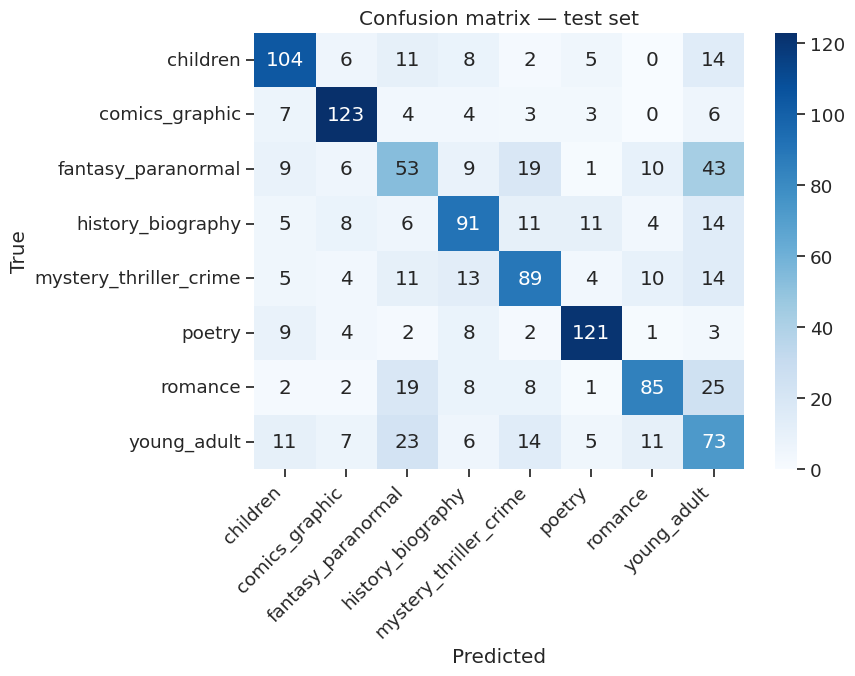

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels_arr, test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion matrix — test set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

## 19. Log final metrics & artifacts to W&B

In [24]:
wandb.log({
    'final/val_loss':      val_results['eval_loss'],
    'final/val_accuracy':  val_results['eval_accuracy'],
    'final/val_f1':        val_results['eval_f1'],
    'final/test_loss':     test_results['eval_loss'],
    'final/test_accuracy': test_results['eval_accuracy'],
    'final/test_f1':       test_results['eval_f1'],
})

artifact = wandb.Artifact('eval-report', type='evaluation')
artifact.add_file('eval_report.json')
artifact.add_file('confusion_matrix.png')
wandb.log_artifact(artifact)
wandb.finish()

eval/accuracy,▁▆▆▆▇▇▇▇▇▇▇▇█
eval/f1,▁▆▇▇▇▇▇▇▇▇▇▇█
eval/loss,█▃▂▂▂▂▂▂▂▂▂▂▁
eval/runtime,▁▃▄▅▆▇▇▇████▇
eval/samples_per_second,█▆▅▃▂▂▂▂▁▁▁▁▁
eval/steps_per_second,█▆▅▃▂▂▂▂▁▁▁▁▁
final/test_accuracy,▁
final/test_f1,▁
final/test_loss,▁
final/val_accuracy,▁
+13,...


## 18. Save Model to Hugging Face Hub

In [29]:
from huggingface_hub import login

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
 
# HF_TOKEN was already loaded from Kaggle Secrets (see Task 4)
login(token=HF_TOKEN)
 
# Push model and tokenizer
model.push_to_hub("sumitp76/distilroberta-base-goodreads-genres")
tokenizer.push_to_hub("sumitp76/distilroberta-base-goodreads-genres")

# Initiate wandb
wandb.init(
    project="mlops-assignment2",
    name=run_name
)
 
# Record the link in W&B
wandb.run.summary["huggingface_model"] = \
    "https://huggingface.co/sumitp76/distilroberta-base-goodreads-genres"

# Disconnect wandb
wandb.finish()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


huggingface_model,https://huggingface....
